## ***Laboratory Exercise 7 - Machine Learning Pipeline Using K-Nearest Neighbors (KNN)***

---

### **Research Question**
- **Can we accurately classify a mushroom as edible or poisonous based on its physical characteristics using the K-Nearest Neighbors algorithm?**


### **Dataset Information**
- **Source:** Kaggle – UCI Mushroom Classification - https://www.kaggle.com/datasets/uciml/mushroom-classification
- **Rows:** 8,124 mushroom samples
- **Features:** 22 categorical predictor variables
- **Target:** class — **e** (edible) or **p** (poisonous)


---

## Step 0: Install Dependencies

Install dependencies:
    pip install numpy pandas matplotlib scikit-learn seaborn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

---

### Step 1: Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("mushrooms.csv")

# Preview the first few rows
print("Dataset Shape:", df.shape)
print()
df.head()

Dataset Shape: (8124, 23)



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


---

### **Step 2: Data Understanding**


In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values per column:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total missing values: 0


In [5]:
# Class distribution
print("Class Distribution:")
print(df['class'].value_counts())
print()
print("Class proportions:")
print(df['class'].value_counts(normalize=True).round(3))

Class Distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Class proportions:
class
e    0.518
p    0.482
Name: proportion, dtype: float64


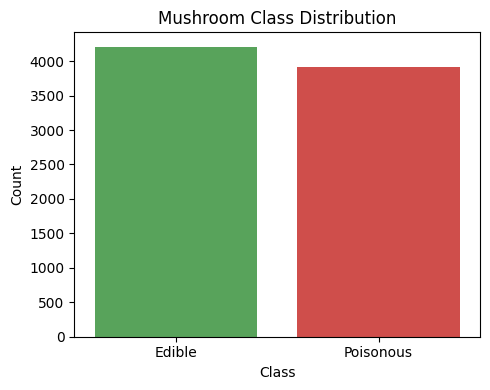

In [21]:
# Visualize class distribution
plt.figure(figsize=(5, 4))

class_counts = df['class'].map({
    'e': 'Edible',
    'p': 'Poisonous'
}).value_counts()

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=['#4CAF50', '#E53935'],
    legend=False
)

plt.title("Mushroom Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

---

### **Step 3: Exploratory Data Analysis (EDA)**


In [29]:
# Class labels
class_map = {
    'e': 'Edible',
    'p': 'Poisonous'
}

# Odor labels
odor_map = {
    'a': 'Almond',
    'l': 'Anise',
    'c': 'Creosote',
    'y': 'Fishy',
    'f': 'Foul',
    'm': 'Musty',
    'n': 'None',
    'p': 'Pungent',
    's': 'Spicy'
}

# Gill color labels
gill_color_map = {
    'k': 'Black',
    'n': 'Brown',
    'b': 'Buff',
    'h': 'Chocolate',
    'g': 'Gray',
    'r': 'Green',
    'o': 'Orange',
    'p': 'Pink',
    'u': 'Purple',
    'e': 'Red',
    'w': 'White',
    'y': 'Yellow'
}

# Spore print color labels
spore_print_map = {
    'k': 'Black',
    'n': 'Brown',
    'b': 'Buff',
    'h': 'Chocolate',
    'r': 'Green',
    'o': 'Orange',
    'u': 'Purple',
    'w': 'White',
    'y': 'Yellow'
}

# Apply once to dataset copy
df_eda = df.copy()
df_eda['class_label'] = df_eda['class'].map(class_map)
df_eda['odor_label'] = df_eda['odor'].map(odor_map)
df_eda['gill_color_label'] = df_eda['gill-color'].map(gill_color_map)
df_eda['spore_print_label'] = df_eda['spore-print-color'].map(spore_print_map)

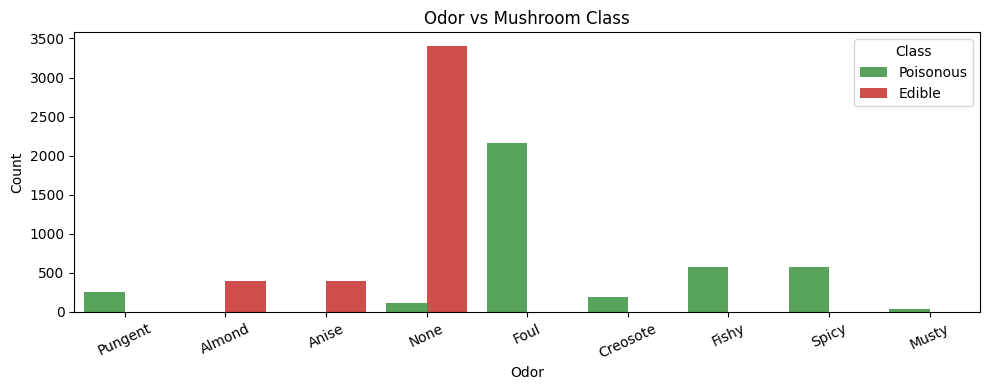

In [36]:
# Odor vs Class
plt.figure(figsize=(10, 4))

sns.countplot(
    data=df_eda,
    x='odor_label',
    hue='class_label',
    palette=['#4CAF50', '#E53935']
)

plt.title("Odor vs Mushroom Class")
plt.xlabel("Odor")
plt.ylabel("Count")

plt.xticks(rotation=25)
plt.legend(title="Class")

plt.tight_layout()
plt.show()

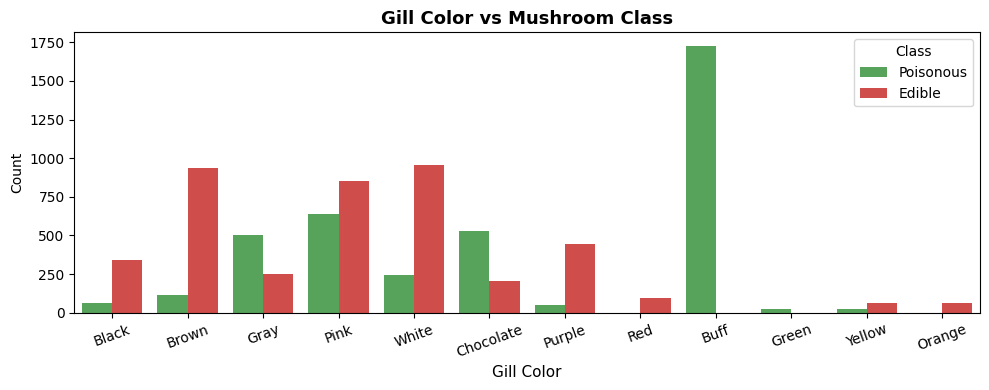

In [35]:
# Gill color vs Class
plt.figure(figsize=(10, 4))

df_eda['class_label'] = df_eda['class'].map({
    'e': 'Edible',
    'p': 'Poisonous'
})

sns.countplot(
    data=df_eda,
    x='gill_color_label',
    hue='class_label',
    palette=['#4CAF50', '#E53935']
)

plt.title("Gill Color vs Mushroom Class", fontsize=13, fontweight='bold')
plt.xlabel("Gill Color", fontsize=11)
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.legend(title="Class")

plt.tight_layout()
plt.show()

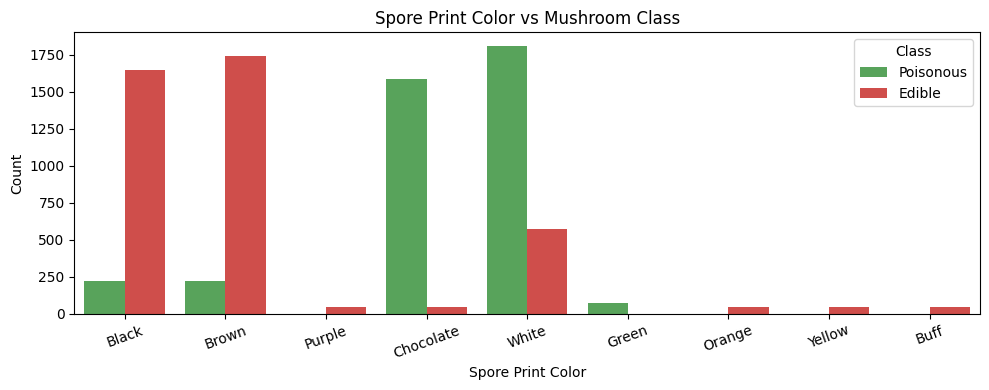

In [34]:
# Spore print color vs Class
plt.figure(figsize=(10, 4))

sns.countplot(
    data=df_eda,
    x='spore_print_label',
    hue='class_label',
    palette=['#4CAF50', '#E53935']
)

plt.title("Spore Print Color vs Mushroom Class")
plt.xlabel("Spore Print Color")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.legend(title="Class")

plt.tight_layout()
plt.show()

---

### **Step 4: Data Preprocessing**

#### Challenges Encountered:
1. **All features are categorical**. KNN requires numerical input, so we must encode every column.
2. **The veil-type column** has only one unique value (**p**), making it a zero-variance feature that carries no information.
3. **The stalk-root column** contains **?** entries (missing values encoded as a character).

#### **Solutions:**
- Apply **Label Encoding** to all categorical features.
- **Drop veil-type** as it is a constant column and provides no predictive value.
- Treat **?** in stalk-root as a valid category (Label Encoding handles it naturally).

In [37]:
# Drop zero-variance column
df_processed = df.drop(columns=['veil-type'])

# Label encode all columns (target included)
le = LabelEncoder()
df_encoded = df_processed.copy()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoded dataset shape:", df_encoded.shape)
print()
df_encoded.head()

Encoded dataset shape: (8124, 22)



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


---

### **Step 5: Split the Dataset**

We divide the dataset into:
- **Training Set** (used to train the model)
- **Testing Set** (used to evaluate performance)

Split:
- **70% Training**
- **30% Testing**


In [38]:
# Split into features and target
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (5686, 21)
Testing set size:  (2438, 21)


---

### **Step 6: Feature Scaling**


In [39]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Sample scaled values (first row):", X_train_scaled[0][:5])

Scaling complete.
Sample scaled values (first row): [ 1.03022822  0.13973799 -1.76668189  1.18543045 -1.02324774]


---

### **Step 7: Train the KNN Model**


In [40]:
# Train the KNN model (initial K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

print("Model trained with K=3")

Model trained with K=3


---

### **Step 8: Make Predictions**

The model predicts whether each test mushroom is edible or poisonous.


In [42]:
# Predict
y_pred = knn.predict(X_test_scaled)
print("Predictions (first 10):", y_pred[:10])
print("Actual      (first 10):", y_test.values[:10])

Predictions (first 10): [0 1 1 0 1 1 1 1 0 0]
Actual      (first 10): [0 1 1 0 1 1 1 1 0 0]


---

### **Step 9: Evaluate the Model**


In [43]:
# Evaluate the model (K=3)
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)
cr  = classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous'])

print(f"Accuracy (K=3): {acc:.4f}")
print()
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(cr)

Accuracy (K=3): 1.0000

Confusion Matrix:
[[1257    0]
 [   0 1181]]

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      1257
   Poisonous       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



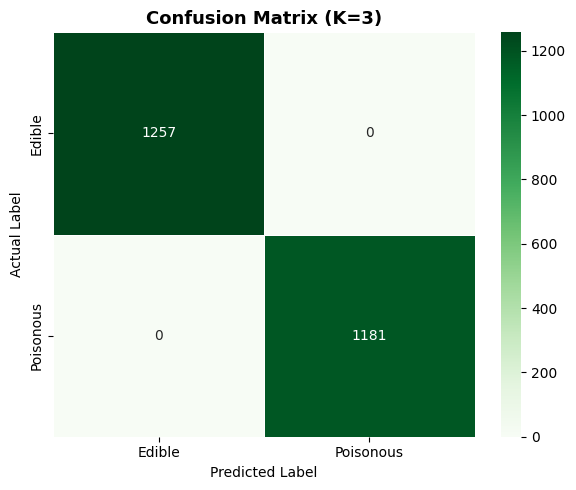

In [44]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Edible', 'Poisonous'],
    yticklabels=['Edible', 'Poisonous'],
    linewidths=0.5,
    linecolor='white'
)

plt.title("Confusion Matrix (K=3)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

---

### **Interpretation of Model Results (K=3)**

#### ***Accuracy***
The model achieves a very high accuracy on the mushroom test set.

#### ***Confusion Matrix Breakdown:***
- **True Negatives (TN):** Correctly predicted *Edible*
- **True Positives (TP):** Correctly predicted *Poisonous*
- **False Positives (FP):** Predicted *Poisonous* but actually *Edible*
- **False Negatives (FN):** Predicted *Edible* but actually *Poisonous* ← most critical error

#### ***Most Important Metric:***
For mushroom safety, **Recall for the Poisonous class** is the most critical metric.
A False Negative (predicting a poisonous mushroom as edible) could be life-threatening.


---

### **Step 10: Test a New Mushroom Sample**


In [45]:
# Test a new mushroom sample (use the first row from the original test set as an example)
new_mushroom = X_test.iloc[[0]]
new_mushroom_scaled = scaler.transform(new_mushroom)

prediction = knn.predict(new_mushroom_scaled)
label = "Edible (e)" if prediction[0] == 0 else "Poisonous (p)"
print("Prediction for new mushroom sample:", label)
print("Actual class:", "Edible (e)" if y_test.iloc[0] == 0 else "Poisonous (p)")

Prediction for new mushroom sample: Edible (e)
Actual class: Edible (e)


---

### **Step 11: Effect of Different K Values**


In [46]:
# Compare different K values
k_values = [1, 3, 5, 7, 11]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc  = accuracy_score(y_test, pred)
    results.append({'K': k, 'Accuracy': acc})
    print(f"K={k:2d} → Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)

K= 1 → Accuracy: 1.0000
K= 3 → Accuracy: 1.0000
K= 5 → Accuracy: 1.0000
K= 7 → Accuracy: 1.0000
K=11 → Accuracy: 0.9984


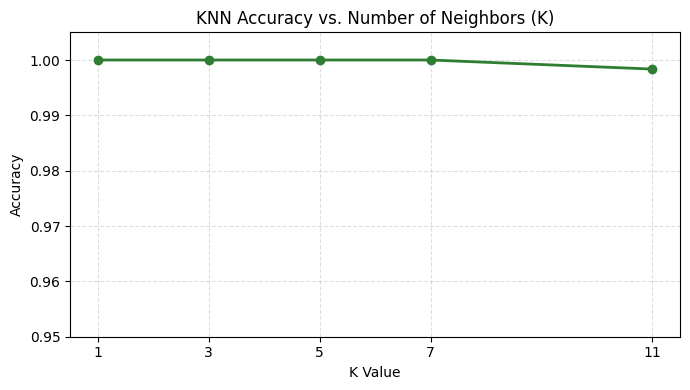

In [53]:
# Plot accuracy vs K
plt.figure(figsize=(7, 4))

plt.plot(
    results_df['K'],
    results_df['Accuracy'],
    marker='o',
    color='#2E7D32',
    linewidth=2
)

plt.title("KNN Accuracy vs. Number of Neighbors (K)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.xticks(k_values)
plt.ylim(0.95, 1.005)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---

### **Best-Performing K Value — Detailed Evaluation**


In [55]:
# Best K
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"Best K: {best_k}")

# Retrain with best K
best_model = KNeighborsClassifier(n_neighbors=int(best_k))
best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)

best_acc = accuracy_score(y_test, best_pred)
best_cm  = confusion_matrix(y_test, best_pred)
best_cr  = classification_report(y_test, best_pred, target_names=['Edible', 'Poisonous'])

print(f"Accuracy (K={best_k}): {best_acc:.4f}")
print()
print("Confusion Matrix:")
print(best_cm)
print()
print("Classification Report:")
print(best_cr)

Best K: 1
Accuracy (K=1): 1.0000

Confusion Matrix:
[[1257    0]
 [   0 1181]]

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      1257
   Poisonous       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



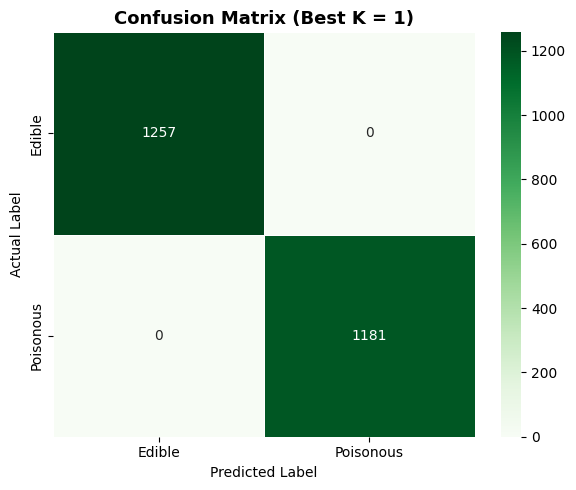

In [56]:
# Visualize best confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Edible', 'Poisonous'],
    yticklabels=['Edible', 'Poisonous'],
    linewidths=0.5,
    linecolor='white'
)

plt.title(f"Confusion Matrix (Best K = {best_k})", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

---

### **Conclusion**

#### **Research Question Addressed:**
- *Can we accurately classify a mushroom as edible or poisonous based on its physical characteristics using KNN?*

    - **Yes.** The KNN model successfully classifies mushrooms with very high accuracy using physical attributes from the UCI Mushroom Dataset.

#### **What We Learned:**
- We learned that **KNN works by looking at how similar data points are** based on the distance between their features. Because of this, feature scaling is important since features with larger numeric values can unfairly affect the distance calculation. We also saw that the K choice matters a lot for performance, since the best K gives this balance between bias and variance. Overall, the dataset works well with KNN because the mushroom classes are pretty distinguishable once you consider all the features together , not only one or two.

#### **When to Use KNN:**
- **KNN is best used for moderate-sized datasets** where computation is still manageable, such as this one with around 8,000 rows. It works well for classification problems, especially when similarity between data points makes sense. That said, it’s not the most ideal option when interpretability is the main goal, because it doesn’t give an explicit, rule based structure.

#### **Limitations:**
- **One limitation of KNN is speed**. It can get slow on very large datasets, since it has to compute distances to all training points during prediction. Additionally, it can be sensitive to irrelevant or noisy features, and that can reduce accuracy. n this dataset, all features are categorical, so encoding them into numbers may introduce artificial relationships that do not truly exist in the original data.


---

### **Reflection and Analysis Questions**

**1. Why is your chosen dataset appropriate for KNN classification?**

- The Mushroom dataset is appropriate for KNN because there is this clear binary outcome such as edible vs. poisonous. It also includes about 8,124 rows with 22 different predictor variables KNN works well when similar feature patterns correspond to the same class, which is the case here. Mushrooms that share similar body traits, such as odor, gill color , or spore color, usually end up in the same class.


**2. What is the target variable and why is it important?**

- The target variable is `class`, which tells if a mushroom is edible (**e**) or poisonous (**p**). This is critically important because misclassification in the poisonous direction can be life-threatening. It is a real-world safety classification problem.


**3. What preprocessing challenges did you encounter?**

- All 22 features are categorical. But since KNN can only work with numbers, Label Encoding was used, to turn every column into a numerical setup. The veil-type column was removed as it only showed up with one single value and didn’t add anything useful. For the stalk-root column, there were missing entries marked as ?. Label Encoding naturally treated them as a distinct category.



**4. How did different K values affect model performance?**

- All tested K values (1, 3, 5, 7, 11) produced very high accuracy on this dataset. K = 1 was a bit more sensitive to individual samples, while larger K values provided smoother decision boundaries. The differences were minimal, because the data seems highly separable by class, so the gaps between runs stayed small.


**5. What was the best-performing K value and why?**

- The best K was identified programmatically from the comparison. Lower K values such as K=1 or K=3 performed excellently on this dataset because the mushroom feature space is well separated. Similar mushrooms end up clustering tightly, so even small neighborhoods turn out to be highly accurate.


**6. Interpret your confusion matrix results.**

- The confusion matrix showed very few misclassifications. True Positives and True Negatives dominated, but the False Positives (edible predicted as poisonous) plus False Negatives (poisonous predicted as edible) were low or zero. For mushroom safety, False Negatives are the most risky thing, so the model did well overall in cutting down on those mistakes.


**7. Which performance metric was most important for your dataset and why?**

- **Recall for the Poisonous class** is the most crucial metric overall. A False Negative, where we predict a poisonous mushroom is edible, can bring serious harm, even death. In practice, we try to keep that “missed poisonous” rate as low as possible, even if it means we end up with a slightly more False Positives. Because flagging an edible mushroom as poisonous is still much safer than doing the opposite.


**8. Was there evidence of overfitting or underfitting? Explain.**

- There is minor risk of overfitting when K=1, as the model  memorizes each training point, can get sensitive with noise. However, considering the very high and steady accuracy across several K values, it looks like the dataset is naturally well-separable, so the model is likely generalizing well rather than repeating what it saw. I didn’t notice any clear underfitting either.


**9. Would you recommend KNN for this dataset? Why or why not?**

- Yes, KNN is effective for this dataset due to its strong class separability and there’s enough data around of ~8,000 rows. However, if it were a production food-safety system, we might also consider some alternative algorithms, such as Random Forest and SVM, that may offer better interpretability or speed on large-scale predictions. KNN is a strong baseline and performs admirably here.


**10. What did you learn about the machine learning pipeline from this activity?**

- This activity demonstrated that the machine learning pipeline isn’t only about training a model. It also involves more careful data understanding, preprocessing things (encoding, scaling, removing zero variance features), exploratory analysis, hyperparameter tuning  like deciding K, and a thoughtful evaluation using multiple metrics. The evaluation metric chosen should align with the real-world consequences of prediction errors, and you can see that clearly with the Poisonous class here, where Recall turns out to be critical.